# propygator

**A Python library for orbital simulation and satellite tracking**, built on
[Orekit](https://www.orekit.org/). Hand it a state vector or a two-line element set and it
propagates, plots, exports, predicts ground passes, and fits new element sets — with the
physics measured against *real orbits*, not only against its own tests.

This page is the short tour. Every number and figure below is produced by the code shown,
executed top to bottom; the last two sections summarize a separate validation study against
laser-ranging and GPS truth data.

**Source:** [github.com/hzhang2718-bit/propygator](https://github.com/hzhang2718-bit/propygator)

In [ ]:
import numpy as np

import propygator as pgr

pgr.__version__

In [ ]:
# Display configuration for the rendered page (not part of propygator's API).
%matplotlib inline
%config InlineBackend.figure_format = "retina"

import pandas as pd
import plotly.io as pio
from matplotlib.colors import LinearSegmentedColormap

# nbconvert's HTML template carries no JupyterLab plotly renderer, so ask plotly for
# self-describing HTML output rather than a mimebundle.
pio.renderers.default = "notebook_connected"

SERIES = ["#2a78d6", "#eb6834", "#1baf7a"]
INK_MUTED, GRID = "#898781", "#e1e0d9"

# One-hue sequential ramp for the table shading (blue, light -> dark).
BLUES = LinearSegmentedColormap.from_list(
    "pgr_blues", ["#cde2fb", "#9ec5f4", "#5598e7", "#2a78d6", "#184f95"]
)


def tidy(ax, *, xlabel="", ylabel="", title="", pad=6):
    """Recessive chrome: hairline grid, no top/right spine, muted tick ink."""
    ax.set_xlabel(xlabel, color=INK_MUTED)
    ax.set_ylabel(ylabel, color=INK_MUTED)
    if title:
        ax.set_title(title, loc="left", fontsize=11, color="#0b0b0b", pad=pad)
    ax.grid(True, color=GRID, linewidth=0.8, alpha=1.0)
    ax.set_axisbelow(True)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_color("#c3c2b7")
    ax.tick_params(colors=INK_MUTED, labelsize=9)
    return ax

## 1 · Propagate an orbit numerically

Start from a Cartesian state — position, velocity, an epoch, and an **explicit frame** —
and integrate forward. The starting point here is the International Space Station's own
state, taken from a pinned element set so this page renders identically every time.

The defaults are a real force model, not a toy: **70×70 EIGEN gravity, Sun and Moon
third-body attraction, NRLMSISE-00 drag, and conical-shadow solar radiation pressure**,
integrated with an adaptive Dormand–Prince 8(5,3). That is one function call.

In [ ]:
ISS_LINE1 = "1 25544U 98067A   26171.41461525  .00008813  00000+0  16600-3 0  9990"
ISS_LINE2 = "2 25544  51.6327 284.1189 0004557 208.5194 151.5545 15.49333088572250"
iss = pgr.TLE.from_strings(ISS_LINE1, ISS_LINE2, name="ISS (ZARYA)")

# The element set's own state at its epoch, converted to an inertial frame.
state0 = pgr.propagate_tle(iss, 60, output_step=60)[0].to_frame(pgr.Frame.EME2000)

traj = pgr.propagate_numerical(
    state0, duration=4 * 3600, output_step=120, progress=False
)

print(
    f"{len(traj)} samples | {traj.frame.name} | "
    f"{traj.start_epoch.to_iso()} -> {traj.end_epoch.to_iso()}"
)

`plot_summary` is the one-call overview: ground track, altitude, and speed for the whole
arc.

In [ ]:
pgr.plot_summary(traj);

The same trajectory in 3-D — **interactive: drag to rotate, scroll to zoom.**

In [ ]:
pgr.plot_3d(traj, frame=pgr.Frame.ITRF, show_map_overlay=True).show()

Every `Trajectory` carries a reproducibility record: the library version, the exact forces
that acted, the integrator, and the spacecraft model. Re-running from the metadata gives
the same arc.

In [ ]:
for key in ("propygator_version", "force_models", "integrator", "spacecraft"):
    print(f"{key:20s} {traj.metadata[key]}")

### When the orbit does something drastic

Drop the same inclination to a 140 km circular orbit and it re-enters within hours.
propygator neither crashes nor returns nonsense: it **warns once** that the orbit fell
below the drag model's free-molecular validity floor, **stops itself at re-entry**, and
hands back the partial trajectory with the reason attached. `duration` is an upper bound,
not a promise.

In [ ]:
import warnings

MU, R_EARTH = 3.986004418e14, 6_378_137.0
r = R_EARTH + 140_000.0
v, inc = np.sqrt(MU / r), np.radians(51.6)

decaying = pgr.State(
    state0.epoch,
    np.array([r, 0.0, 0.0]),
    np.array([0.0, v * np.cos(inc), v * np.sin(inc)]),
    pgr.Frame.EME2000,
)

with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    decay = pgr.propagate_numerical(
        decaying, duration=12 * 3600, output_step=60, progress=False
    )

print(f"warned once : {caught[0].message}" if caught else "no warning")
print(
    f"terminated  : {decay.metadata['termination_reason']} "
    f"at {decay.metadata['termination_epoch']}"
)
print(f"recovered   : {len(decay)} samples up to the crossing")

In [ ]:
pgr.plot_altitude(decay);

## 2 · Propagate a TLE with SGP4/SDP4

Two-line element sets are the standard means of satellite tracking, and they need their own
analytic propagator. `propagate_tle` runs SGP4 (near-Earth) or SDP4 (deep-space)
automatically and returns the **same `Trajectory` type** — so the entire plotting and
export surface from section 1 works unchanged.

The implementation is pinned against Vallado's AIAA 2006-6753 reference vectors.

In [ ]:
tle_traj = pgr.propagate_tle(iss, 4 * 3600, output_step=60)

print(f"{len(tle_traj)} samples | {tle_traj.frame.name} (SGP4's native frame)")
pgr.plot_ground_track(tle_traj);

## 3 · Track it in real time

`live_track` turns that TLE-generated trajectory into a **self-updating dashboard**
— a now-centered rolling buffer re-propagated as it drains, driving a ground track,
altitude, speed, and the observer sky view at 1 Hz. Toolbar zoom and pan survive every
redraw:

```python
durham = pgr.GroundStation("Durham", 35.99, -78.90, altitude_m=130)
anim = pgr.live_track("ISS", durham, tz=pgr.USTimeZone.EASTERN)
```

It is a live animation, so it cannot render on a static page — here is what it looks like:


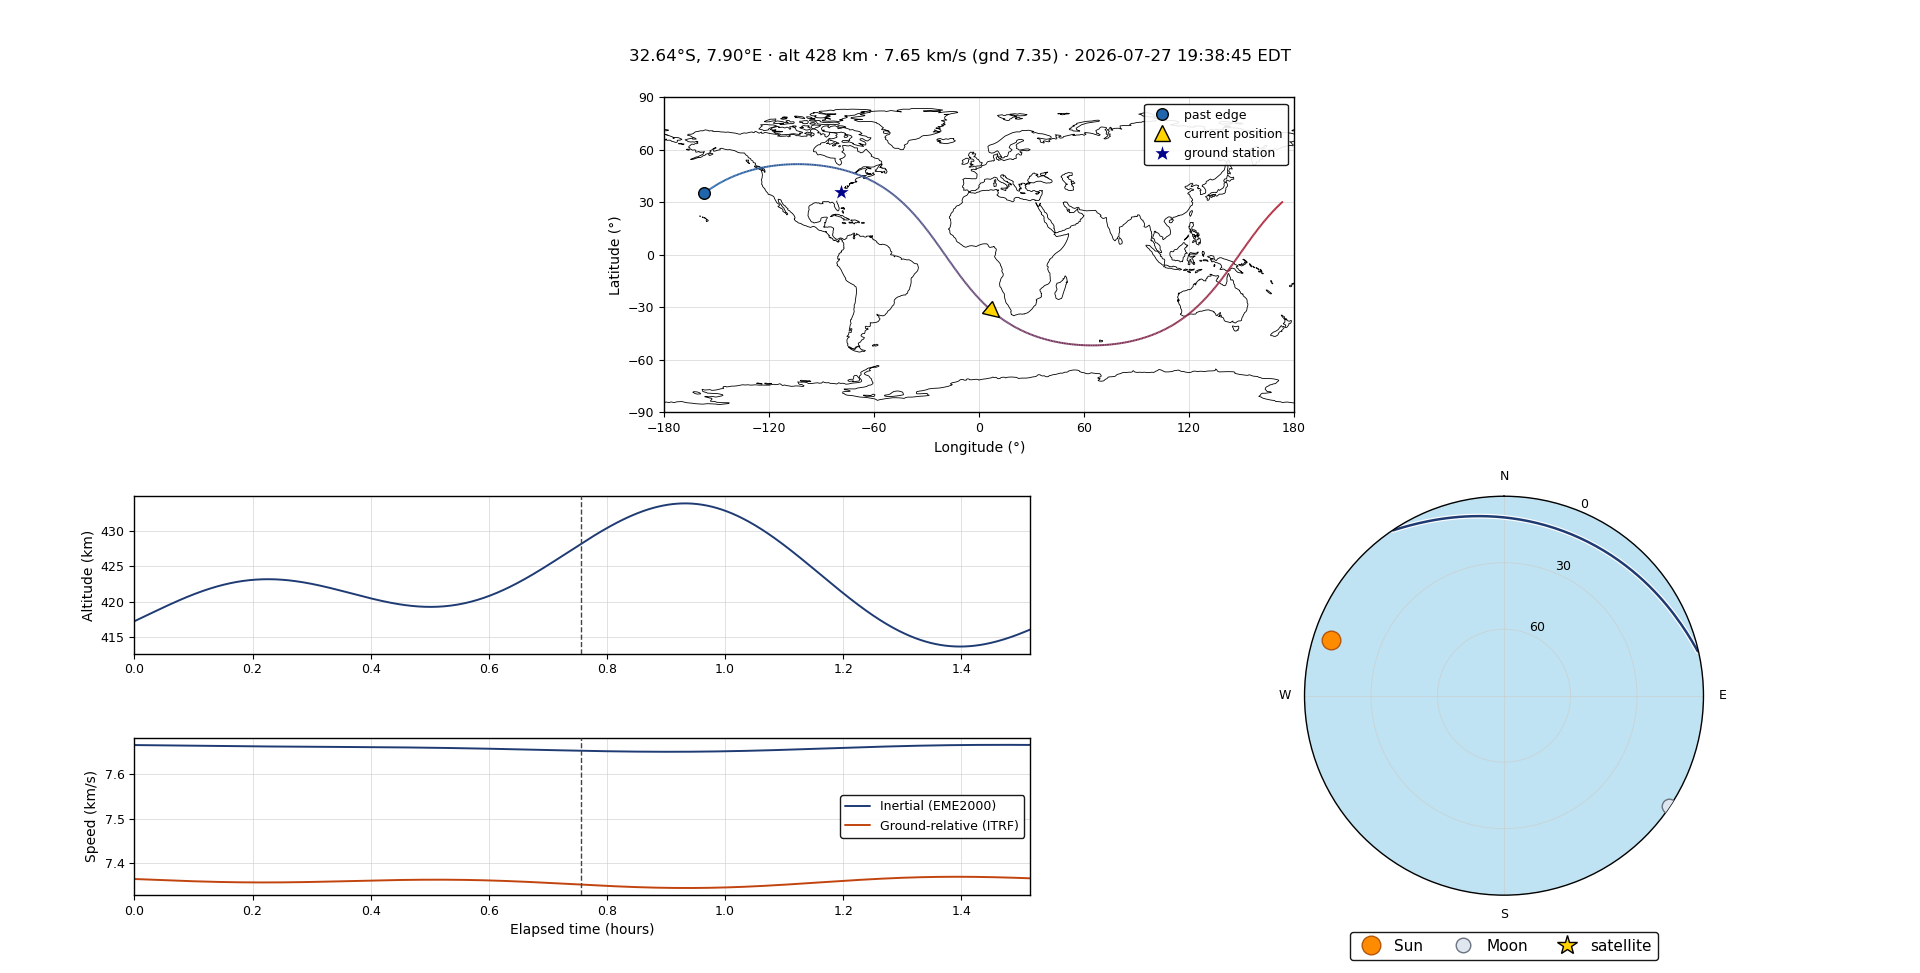

*Ground track with the past-edge, current-position and station markers; altitude and inertial / ground-relative speed either side of the now-line; and the observer's sky view with the Sun and Moon placed. Everything advances once a second.*

## 4 · Predict visible passes

A **pass** is an interval with the satellite above an elevation gate. A *visible* pass adds
physics: the satellite must be sunlit while the observer sits in darkness. `find_passes`
scans the window coarsely, refines each rise / culmination / set to sub-second precision,
runs a conical-umbra shadow test, and applies a phase law for an estimated visual magnitude.

Cross-checked against Skyfield: agreement within 2 seconds and 1 degree over a 10-pass ISS
table.

In [ ]:
start = pgr.Epoch.from_iso("2026-06-23T00:00:00", scale=pgr.TimeScale.UTC)

durham = pgr.GroundStation("Durham", 35.99, -78.90, altitude_m=130)

passes = pgr.find_passes(
    iss, durham, 2 * 86400, start=start, min_elevation_deg=10, progress=False
)
print(f"{len(passes)} visible passes over 2 days from Durham, NC")

One row per pass, with timezone-aware local times, where to look, and how bright it gets.

In [ ]:
pgr.passes_to_dataframe(passes, tz=pgr.USTimeZone.EASTERN)

**Where** to look — each arc split into its sunlit (gold) and eclipsed (gray, dashed)
segments, so you can see exactly where a pass slips into Earth's shadow. The same
passes also export to CSV or to an iCalendar file that imports straight into a
phone calendar (`export_passes_csv` / `export_passes_ics`).

In [ ]:
pgr.plot_sky_chart(iss, durham, passes, tz=pgr.USTimeZone.EASTERN);

## 5 · Fit a new TLE to a trajectory

The inverse problem: given a high-fidelity trajectory, find the element set whose SGP4
propagation best reproduces it. That is a batch least-squares estimation over the six
orbital elements plus the B\* drag term — the way an operator turns their own orbit
knowledge into something shareable.

We refit the numerical arc from section 1.

In [ ]:
fit = pgr.fit_tle_detailed(traj, norad_id=25544, name="ISS (ZARYA)", progress=False)

print(
    f"converged in {fit.iterations} iterations "
    f"({fit.evaluations} evaluations) over {len(fit.residuals_m)} measurements"
)
print(f"post-fit RMS: {fit.rms_m:.0f} m\n")
print(fit.tle.line1)
print(fit.tle.line2)

**A single fit's own residual doesn't tell you whether it will forecast well.** A short free-B\* fit can look great in-arc and still be tens of kilometers wrong days out, because the fit soaks up along-track error into a physically wrong drag coefficient. The measured fix -- validated across ten windows and a second satellite -- is simple: fit B\* free on a longer arc, then **transplant** it onto a fresh, shorter refit via `initial_guess` + `fit_bstar=False`.

In [ ]:
# The measured recipe (docs/tle-fitting-playbook-updated.md): fit B* free on a 2-day
# arc, then transplant it onto a fresh 1-day refit. Both arcs share the same end, so
# a 3-day reference is generated once and sliced from the back.
reference_3d = pgr.propagate_numerical(
    state0, duration=3 * 86400, output_step=600, progress=False
)


def tail(t: pgr.Trajectory, span_s: float) -> pgr.Trajectory:
    n = sum(1 for st in t if t.end_epoch.seconds_since(st.epoch) <= span_s)
    return pgr.Trajectory.from_arrays(
        [st.epoch for st in t][-n:], t.positions[-n:], t.velocities[-n:], t.frame
    )


def bstar_of(t: pgr.TLE) -> float:
    """B* from line 1, columns 54-61 (sign + 5-digit mantissa + signed exponent)."""
    f = t.line1[53:61]
    return (-1.0 if f[0] == "-" else 1.0) * (int(f[1:6]) / 1e5) * 10.0 ** int(f[6:8])


staging = pgr.fit_tle_detailed(
    tail(reference_3d, 2 * 86400),
    fitting_span=2 * 86400,
    norad_id=25544,
    progress=False,
)
recipe = pgr.fit_tle_detailed(
    tail(reference_3d, 86400),
    fitting_span=86400,
    initial_guess=staging.tle,
    fit_bstar=False,
    norad_id=25544,
    progress=False,
)

print(
    f"2-day staging fit : B* = {bstar_of(staging.tle):.3e} | rms {staging.rms_m:.0f} m"
)
print(
    f"1-day carried fit : B* = {bstar_of(recipe.tle):.3e} | rms {recipe.rms_m:.0f} m"
    "  (B* held from staging)"
)

---

## 6 · Measured against real orbits

A test suite can only check that the code agrees with the developer's own understanding.
If a frame convention or a units factor is wired wrong *consistently*, the tests pass and
the physics is still wrong. The only oracle that cannot share that misconception is a
**measured orbit**.

propygator was run against **LAGEOS-2** (centimeter-level ILRS laser-ranging orbits),
**GRACE-FO** (GNV1B GPS reduced-dynamic orbits, ten windows spanning a full solar cycle),
and **Swarm A/B** as a second, less-precisely-known body.

*Numbers below are transcribed from two studies
([findings](https://github.com/hzhang2718-bit/propygator/blob/main/docs/validation-findings.md),
evidence: [real-world](https://github.com/hzhang2718-bit/propygator/tree/main/experiments/real-world-validation)
and [extended](https://github.com/hzhang2718-bit/propygator/tree/main/experiments/extended-validation));
regenerating them needs several gigabytes of truth data not distributed with the repository.*

### LAGEOS-2 vs. laser ranging

LAGEOS-2 is a solid brass-and-aluminum sphere at 5,800 km — almost no drag, so this
isolates the **conservative** force stack and the frame/time plumbing. Propagated for a
week and differenced against the ILRS orbit:

In [ ]:
# Measured, v0.7.2 validation study. Source: docs/validation-findings.md §3
lageos = pd.DataFrame(
    {
        "radial RMS (m)": [0.11, 0.13, 0.28],
        "along-track RMS (m)": [3.62, 10.61, 23.65],
        "cross-track RMS (m)": [0.05, 0.10, 0.16],
        "3D RMS (m)": [3.62, 10.61, 23.65],
        "3D max (m)": [6.19, 18.23, 40.55],
    },
    index=pd.Index(["1 day", "3 days", "7 days"], name="horizon"),
)

lageos.style.format("{:.2f}").background_gradient(
    cmap=BLUES, subset=["3D RMS (m)"]
).set_caption("LAGEOS-2 propagated vs. ILRS precise orbits")

**3.6 m after a full day**, and the error is almost entirely along-track while radial and
cross-track stay sub-meter for the whole week — the recognized signature of the small
unmodeled along-track accelerations (Earth radiation pressure, thermal thrust) that mark
the literature floor for this force set. Nothing is wired backwards.

A companion check flips each of seven force toggles individually and compares the
measured effect against an order independently computed along the truth orbit — every
effect lands inside its predicted window, including two predicted to do *nothing* at all.

### GRACE-FO vs. GPS truth — the drag stack

Drag is the hard part of low Earth orbit, because thermospheric density is genuinely
uncertain. GRACE-FO flies at ~500 km with published GPS-derived truth orbits; an extended
study propagated it, with no fitting, across ten windows spanning a full solar cycle —
quiet through storm.

Day-7 3D RMS vs. truth, median per band (shaded by magnitude):

In [ ]:
# Measured, extended-validation study.
# Source: experiments/extended-validation/README.md "Order-of-magnitude errors"
# (median +7 d 3D RMS across each band's windows, no fit).
grace_drag = pd.DataFrame(
    {
        "Cd = 2.3": [0.96, 18.0, 18.0],
        "sphere table": [1.5, 11.0, 9.4],
        "box table": [6.5, 40.0, 45.0],
    },
    index=pd.Index(["quiet", "active", "storm"], name="band"),
)

grace_drag.style.format("{:.2f} km").background_gradient(
    cmap=BLUES, gmap=np.log10(grace_drag), axis=None
).set_caption("GRACE-FO, +7 d 3D RMS vs. GNV1B truth, no fit (10 windows, median/band)")

No single model wins everywhere. `Cd = 2.3` wins in quiet conditions; the per-face
**sphere table** takes the lead once drag is active, roughly halving the storm-peak error
against the constant; the **box table** is the weakest choice in every band measured.

The same pattern held on Swarm A/B, a second satellite whose mass and geometry are
estimated rather than measured — errors run larger there as a direct result.

### The TLE fitter, validated at scale

Section 5's two-stage recipe was benchmarked against every fixed alternative across the
same ten windows and four solar-activity bands, under a pre-registered tie rule, and had
the highest hit rate of any strategy tested. Forward forecast accuracy, by band:

In [ ]:
# Measured, extended-validation study.
# Source: experiments/extended-validation/README.md "Order-of-magnitude errors"
# (median +7 d 3D RMS, arm_transplant recipe -- section 5).
tle_forecast = pd.DataFrame(
    {"+7 d 3D RMS (km)": [9.1, 11.0, 21.0]},
    index=pd.Index(["quiet", "active", "storm"], name="band"),
)

tle_forecast.style.format("{:.1f}").background_gradient(
    cmap=BLUES, axis=None
).set_caption(
    "The recipe's forward forecast error, by solar-activity band (10 windows)"
)

A week out, error still tracks solar activity rather than blowing up arbitrarily — the
same discipline behind section 5's live fit, now shown to hold broadly rather than on one
lucky arc.

---

## Where to go next

Each feature has a full walkthrough notebook:

| | |
|---|---|
| [`01_intro`](https://github.com/hzhang2718-bit/propygator/blob/main/notebooks/01_intro.ipynb) | the five-minute on-ramp |
| [`02_numerical_propagation`](https://github.com/hzhang2718-bit/propygator/blob/main/notebooks/02_numerical_propagation.ipynb) | force models, spacecraft geometry, attitude laws, altitude guards, exports |
| [`03_demo`](https://github.com/hzhang2718-bit/propygator/blob/main/notebooks/03_demo.ipynb) | four contrasting orbits, end to end |
| [`04_tle_propagation`](https://github.com/hzhang2718-bit/propygator/blob/main/notebooks/04_tle_propagation.ipynb) | fetch and propagate element sets with SGP4/SDP4 |
| [`05_realtime_tracking`](https://github.com/hzhang2718-bit/propygator/blob/main/notebooks/05_realtime_tracking.ipynb) | real-time primitives, sky view, the live dashboard |
| [`06_pass_prediction`](https://github.com/hzhang2718-bit/propygator/blob/main/notebooks/06_pass_prediction.ipynb) | visible passes, magnitudes, calendar export |
| [`07_tle_fitting`](https://github.com/hzhang2718-bit/propygator/blob/main/notebooks/07_tle_fitting.ipynb) | the fitter, its diagnostics, and the strategy gate |

And the reference material: the [design and architecture](https://github.com/hzhang2718-bit/propygator/blob/main/docs/architecture.md), the
[validation findings](https://github.com/hzhang2718-bit/propygator/blob/main/docs/validation-findings.md), and the
[repository itself](https://github.com/hzhang2718-bit/propygator).

propygator is MIT-licensed and built on [Orekit](https://www.orekit.org/).